In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from Bio import SeqIO
import os
from collections import Counter
import scipy
from scipy.stats import mannwhitneyu, chi2_contingency,ks_2samp,kruskal, spearmanr
from matplotlib.patches import Patch



plt.rcParams.update({'font.family':'Arial'})




In [159]:
base_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/code/'


fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'

In [160]:
species = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/select_species_for_analysis/shared_species_for_analysis.csv')
species = species.set_index('species_id_VMGC')
species_list = species.index.tolist()
species

,species,species_id_GTDB,num_samples_GTDB,num_samples_VMGC
species_id_VMGC,,,,
988598,Lactobacillus crispatus,100122,135,135
240891,Lactobacillus iners,100505,120,121
783244,Bifidobacterium vaginale,100323,78,78
619501,Fannyhessea vaginae,103895,65,43
571325,Lactobacillus jensenii,100515,35,35
611554,Lactobacillus gasseri,100460,20,20


In [161]:
genome_info = pd.read_csv(f'genomes_info_source_and_genome_type.csv')
genome_info['species_name'] = genome_info['species'].map(species['species'])

midas_ann_full = pd.read_excel(f'{base_dir}/GTDB/classify_GTDB_sources/six_species_origins.xlsx', index_col=0)
midas_ann_full['species_name'] = midas_ann_full['species'].map(species.reset_index().set_index('species_id_GTDB')['species'])
midas_ann_full = midas_ann_full.drop_duplicates('Assembly Accession')
midas_ann_full = midas_ann_full.set_index('Assembly Accession')

midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('urine','urinary tract')
midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('gastrointestinal','gastrointestinal tract')
midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('female reproductive tract','FRT')


midas_genome_to_source = midas_ann_full['human_subcategory'].to_dict()

In [162]:



def fill_source(row):

    if row['genome'] in  midas_genome_to_source:

        source = midas_genome_to_source[row['genome']]
        if not pd.isna(source):
            return source

    if row['database'] in ['VMGC','shared']:
        return 'FRT'

    else:
        return 'unknown'

genome_info['source'] = genome_info.apply(fill_source, axis=1)
genome_info['source'].value_counts()
    

source
FRT                       4776
urinary tract               58
non-human                   50
gastrointestinal tract      14
unknown                     10
other                        5
respiratory                  4
oral                         2
Name: count, dtype: int64

### Extract annotation info

In [163]:
counts = []

for genome in genome_info['genome'].values:

    ### GENOMAD VIRUS
    genomad_virus = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/genomad_virus/{genome}_virus_summary.tsv'  
    df = pd.read_csv(genomad_virus, sep='\t')

    num_viral_seqs = df.shape[0]
    num_integrated_seqs = df['coordinates'].dropna().shape[0]
    num_non_integrated_seqs = df[df['coordinates'].isna()].shape[0]

    ### GENOMAD PLASMID
    genomad_plasmid = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/genomad_plasmid/{genome}_plasmid_summary.tsv'  
    df = pd.read_csv(genomad_plasmid, sep='\t')
    num_plasmids = df.shape[0]

    # ### DISINFINDER     
    disinfinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/DisinFinder/{genome}_DisinFinder_results_tab.txt'  
    df = pd.read_csv(disinfinder, sep='\t')
    num_disinf = df.shape[0]

    ### RESFINDER     
    resfinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/ResFinder/{genome}_ResFinder_results_tab.txt'  
    df = pd.read_csv(resfinder, sep='\t')
    num_resfinder = df.shape[0]
    num_lsa = df[df['Resistance gene'] == 'lsa(C)'].shape[0]
    num_tet = df[df['Resistance gene'] == 'tet(M)'].shape[0]
    num_erm = df[df['Resistance gene'] == 'erm(B)'].shape[0]

    ### MEFINDER     
    mefinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/mefinder/{genome}_mefinder.csv'  
    df = pd.read_csv(mefinder, comment='#')
    num_IS = df[df['type'] == 'insertion sequence'].shape[0]
    num_transposons = df[df['type'].isin(['ice', 'composite transposon', 'unit transposon'])].shape[0]

    counts += [[genome,num_viral_seqs,num_integrated_seqs,num_non_integrated_seqs,num_plasmids,num_disinf,num_resfinder,num_lsa, num_tet, num_erm, num_IS, num_transposons]]

counts_df = pd.DataFrame(counts)
counts_df.columns = ['genome','num_viral_seqs','num_integrated_seqs','num_non_integrated_seqs','num_plasmids',
                    'num_disinf',
                    'num_resfinder','num_lsa', 'num_tet', 'num_erm','num_IS', 'num_transposons']
counts_df = counts_df.set_index('genome')

counts_df = genome_info.merge(counts_df, left_on='genome', right_index=True)


In [164]:
species_order = ['Lactobacillus crispatus',
                                'Lactobacillus iners',
                                'Lactobacillus jensenii',
                                'Lactobacillus gasseri',
                                'Bifidobacterium vaginale',
                                'Fannyhessea vaginae']

### Add quality info

In [165]:
quality_agg = pd.concat([gtdb_quality, vmgc_quality])

In [166]:
quality_agg

,CheckM contamination,CheckM completeness,Assembly Stats Total Sequence Length,Quality_score,BioSample_ID,Collection/isolation_source,Type,Genome_size_(bp),No._of_contigs,N50_length_(bp),...,%_GC_content,%_Completeness,%_Contamination,Clade_separation_score_(GUNC),Presence_of_5S_rRNA,Presence_of_16S_rRNA,Presence_of_23S_rRNA,No._of_tRNA,Genome_quality,Species-level_genomic_bin_(95%_ANI)
GCF_000418345.1,0.47,98.37,2983456.0,96.02,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GCA_000647755.1,1.64,92.70,2819947.0,84.50,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GCA_000709475.1,0.19,93.66,3052055.0,92.71,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GCA_000732745.1,0.67,77.83,2911065.0,74.48,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GCA_000934185.1,0.39,98.11,2756431.0,96.16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR6748217.mbin.3,NaN,NaN,NaN,56.17,SRR6748217,vagina,MAG,931180.0,64.0,20011.0,...,42.62,62.77,1.32,0.41,N,N,N,15.0,medium-quality,SGB026
SRR6748218.mbin.1,NaN,NaN,NaN,58.70,SRR6748218,vagina,MAG,1247995.0,331.0,3923.0,...,39.46,61.40,0.54,0.00,N,N,N,13.0,medium-quality,SGB025
SRR6748219.mbin.1,NaN,NaN,NaN,96.64,SRR6748219,vagina,MAG,1607896.0,18.0,136134.0,...,41.26,99.99,0.67,0.16,N,N,N,20.0,high-quality,SGB004
GCF_029101565.1,NaN,NaN,NaN,90.39,SAMN33310420,endometrium,isolated,1561036.0,1.0,1561036.0,...,42.15,94.09,0.74,0.00,Y,Y,Y,20.0,near-complete,SGB009


In [167]:
# Load dataframes
vmgc_quality = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/VMGC_orig_files/VMGC_prokaryote_MAG.info', sep='\t', index_col=0)
gtdb_quality = pd.read_csv(f'{base_dir}/GTDB/NCBI_genome_quality_info.tsv', sep='\t', index_col=0)

# Calculate GTDB Quality Score
gtdb_quality['Quality_score'] = gtdb_quality['CheckM completeness'] - (5 * gtdb_quality['CheckM contamination'])

# --- Mapping ---

# 1. Map Quality
mapped_vmgc_qual = counts_df['genome'].map(vmgc_quality['Quality_score'])
mapped_gtdb_qual = counts_df['genome'].map(gtdb_quality['Quality_score'])

# 2. Map Completeness (Note the specific column names for each db)
mapped_vmgc_comp = counts_df['genome'].map(vmgc_quality['%_Completeness'])
mapped_gtdb_comp = counts_df['genome'].map(gtdb_quality['CheckM completeness'])

# 3. Map Contamination
mapped_vmgc_cont = counts_df['genome'].map(vmgc_quality['%_Contamination'])
mapped_gtdb_cont = counts_df['genome'].map(gtdb_quality['CheckM contamination'])

# --- Assignment ---

conditions = [
    counts_df['database'].isin(['shared', 'VMGC']),
    counts_df['database'] == 'GTDB'
]

# Assign all three metrics using np.select
counts_df['quality'] = np.select(conditions, [mapped_vmgc_qual, mapped_gtdb_qual], default=np.nan)
counts_df['completeness'] = np.select(conditions, [mapped_vmgc_comp, mapped_gtdb_comp], default=np.nan)
counts_df['contamination'] = np.select(conditions, [mapped_vmgc_cont, mapped_gtdb_cont], default=np.nan)

### Plot differences in number of annotated features per category

In [168]:
def make_broad_categories(source):

    if source == 'FRT' or source == 'non-human':
        return source
    if source in ['urinary tract','gastrointestinal tract', 'other','respiratory', 'oral']:
        return 'all human, non-FRT'
    else:
        return 'unknown'
    
def make_human_nonhuman(source):

    if source == 'non-human':
        return source
    if source in ['FRT', 'urinary tract','gastrointestinal tract', 'other','respiratory', 'oral']:
        return 'human'
    else:
        return 'unknown'


genome_info['broad_source'] = genome_info['source'].apply(make_broad_categories)
genome_info['human_nonhuman'] = genome_info['source'].apply(make_human_nonhuman)

genome_info[['species_name','broad_source']].value_counts().sort_index()


species_name              broad_source      
Bifidobacterium vaginale  FRT                    713
                          all human, non-FRT      18
                          unknown                  1
Fannyhessea vaginae       FRT                    787
Lactobacillus crispatus   FRT                    870
                          all human, non-FRT      20
                          non-human               50
Lactobacillus gasseri     FRT                    203
                          all human, non-FRT      19
                          unknown                  5
Lactobacillus iners       FRT                   1876
                          all human, non-FRT       7
                          unknown                  1
Lactobacillus jensenii    FRT                    327
                          all human, non-FRT      19
                          unknown                  3
Name: count, dtype: int64

In [169]:
counts_df['broad_source'] = counts_df['genome'].map(genome_info.set_index('genome')['broad_source'])
counts_df['human_nonhuman'] = counts_df['genome'].map(genome_info.set_index('genome')['human_nonhuman'])

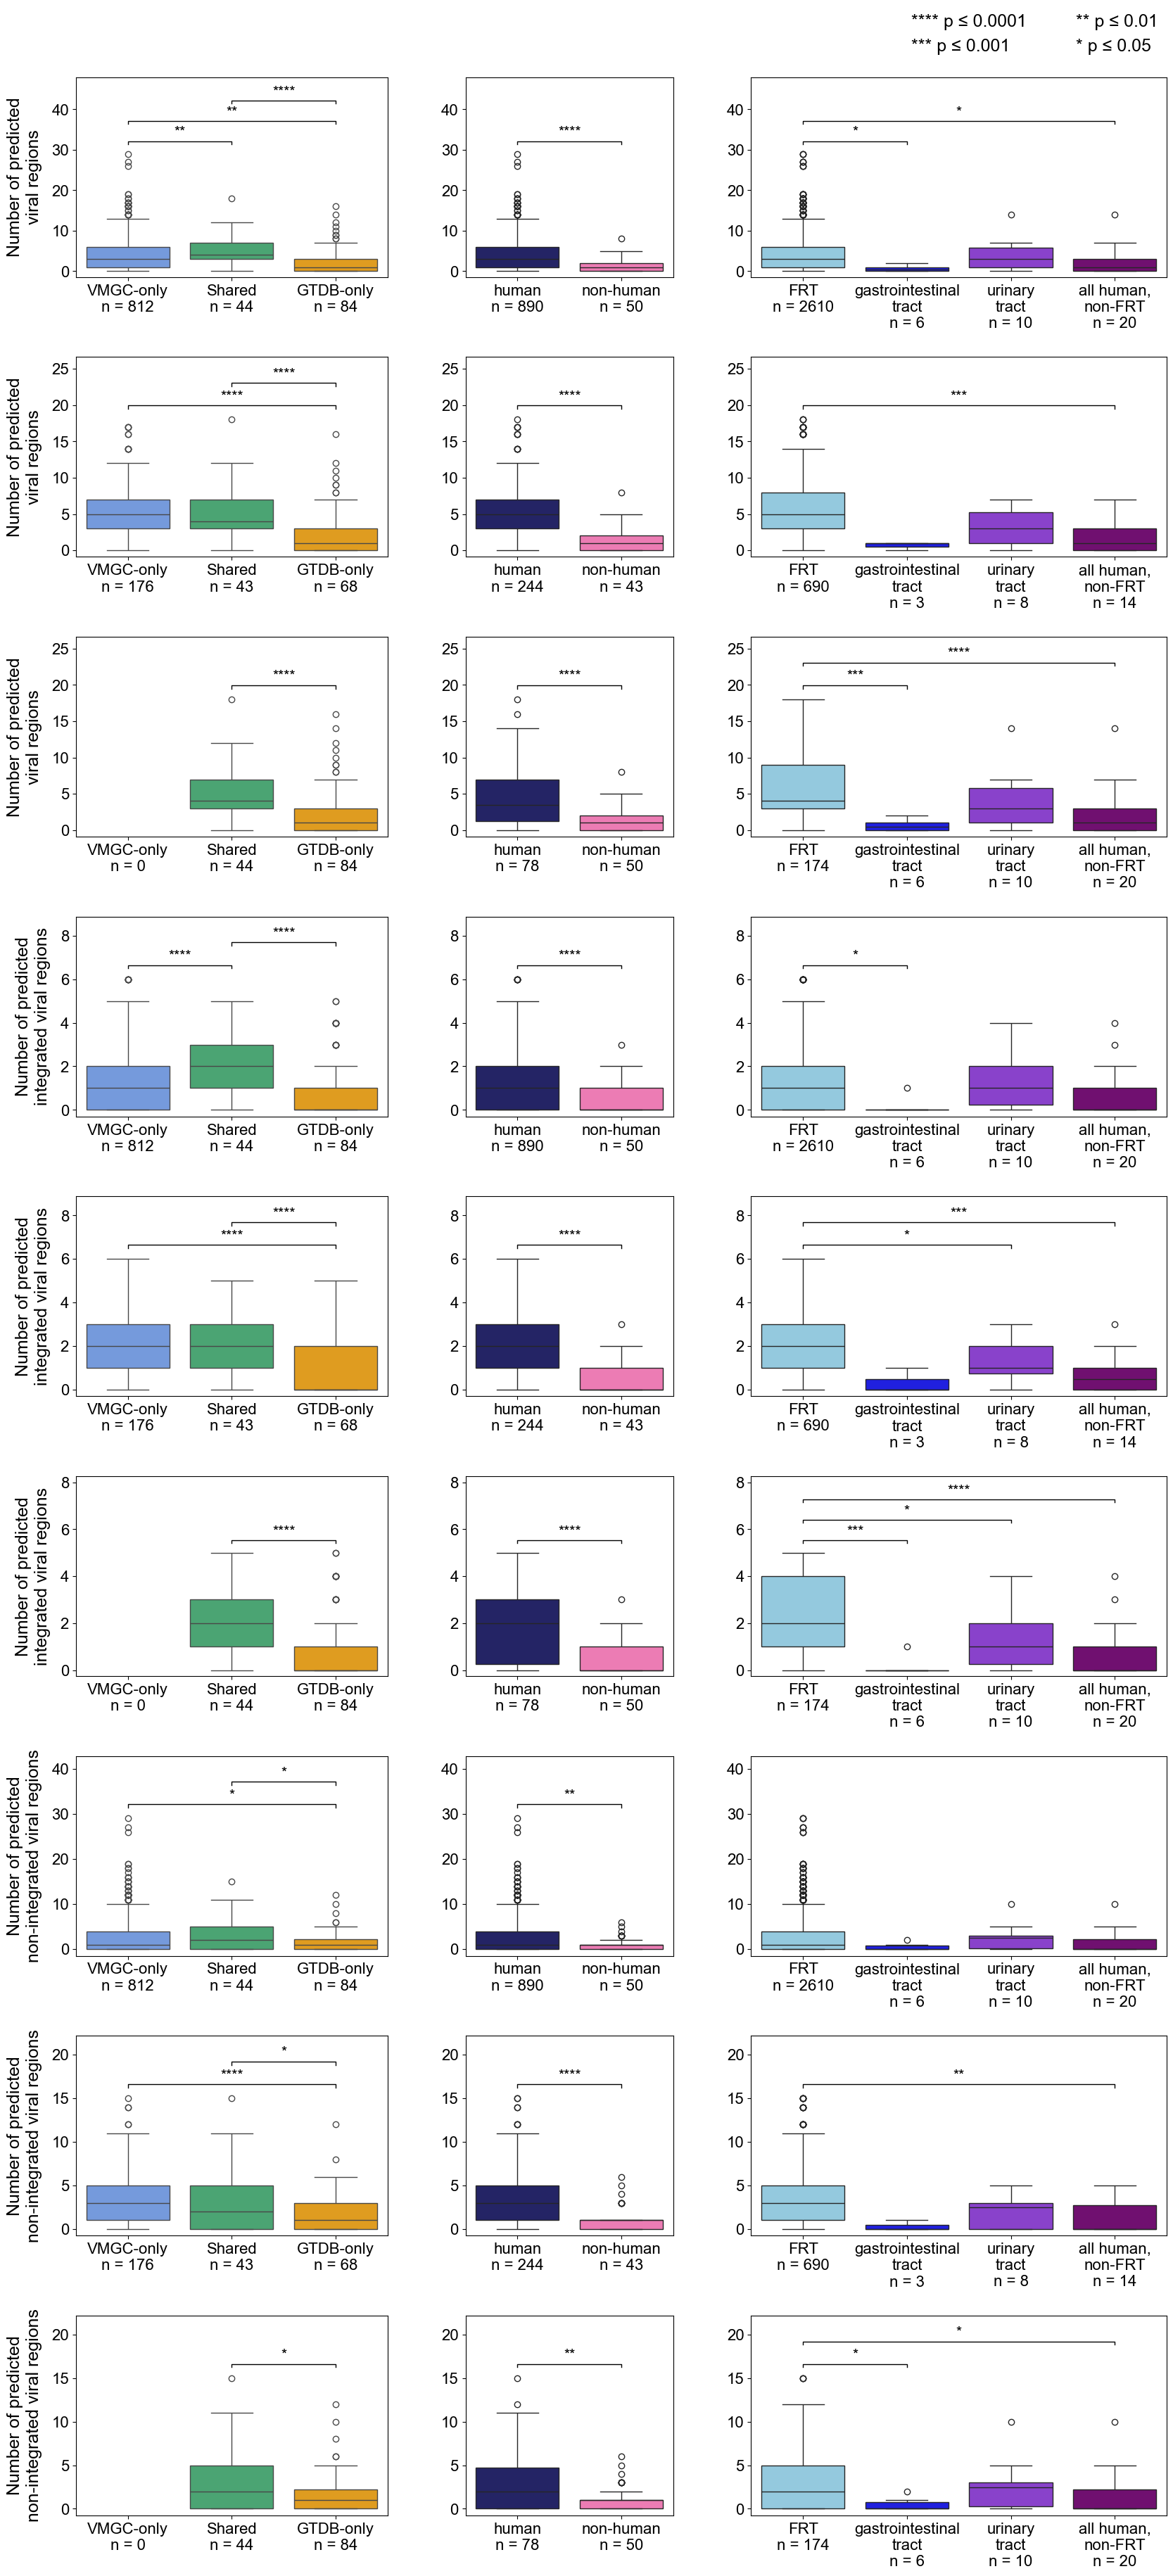

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch

# --- Setup Data ---
# Subset just Lactobacillus crispatus
df_all = counts_df[counts_df['species_name'] == 'Lactobacillus crispatus']

# Create subsets
df_hq = df_all[(df_all['completeness'] >= 90) & (df_all['contamination'] < 5)]
df_iso = df_all[df_all['genome_type'] == 'isolate']

# Colors
my_pal = {
    "human": "midnightblue",
    "non-human": "hotpink",
    "FRT": "skyblue",
    "all human, non-FRT": "purple",
    "urinary tract": "blueviolet",
    "gastrointestinal tract": "blue",
    'MAG': 'lightgray',
    'isolate': 'gray'
}
db_pal = {"VMGC": "cornflowerblue", "shared": "mediumseagreen", "GTDB": "orange"}
db_order = ["VMGC", "shared", "GTDB"]

col_names = {
    "num_viral_seqs": "Number of predicted viral regions",
    "num_integrated_seqs": "Number of predicted integrated viral regions",
    "num_non_integrated_seqs": "Number of predicted non-integrated viral regions",
}

def p_to_stars(p):
    if p <= 0.0001: return "****"
    elif p <= 0.001: return "***"
    elif p <= 0.01: return "**"
    elif p <= 0.05: return "*"
    else: return "ns"

# Comparisons
comparisons = {
    "Human vs. Non-human": ("human_nonhuman", ["human", "non-human"]),
    "FRT vs. GI": ("source", ["FRT", "gastrointestinal tract"]),
    "FRT vs. Urine": ("source", ["FRT", "urinary tract"]),
    "FRT vs. non-FRT human": ("broad_source", ["FRT", "all human, non-FRT"]),
}

# --- Define Rows (9 combinations) ---
row_configs = [
    {"data": df_all, "metric": "num_viral_seqs", "label": "All Genomes\nAll Viral Seqs"},
    {"data": df_hq, "metric": "num_viral_seqs", "label": "HQ Genomes\nAll Viral Seqs"},
    {"data": df_iso, "metric": "num_viral_seqs", "label": "Isolate Genomes\nAll Viral Seqs"},
    
    {"data": df_all, "metric": "num_integrated_seqs", "label": "All Genomes\nIntegrated Seqs"},
    {"data": df_hq, "metric": "num_integrated_seqs", "label": "HQ Genomes\nIntegrated Seqs"},
    {"data": df_iso, "metric": "num_integrated_seqs", "label": "Isolate Genomes\nIntegrated Seqs"},
    
    {"data": df_all, "metric": "num_non_integrated_seqs", "label": "All Genomes\nNon-Integrated Seqs"},
    {"data": df_hq, "metric": "num_non_integrated_seqs", "label": "HQ Genomes\nNon-Integrated Seqs"},
    {"data": df_iso, "metric": "num_non_integrated_seqs", "label": "Isolate Genomes\nNon-Integrated Seqs"}
]

# --- Plotting ---
fig, axs = plt.subplots(9, 3, figsize=(20, 45), gridspec_kw={'width_ratios': [3, 2, 4]})
axs = axs.flatten()

for i, config in enumerate(row_configs):
    df_curr = config["data"]
    metric = config["metric"]
    row_label = config["label"]
    
    row_start = i * 3

    # -------------------------------------------------------
    # Initial Plotting
    # -------------------------------------------------------
    ax_db = axs[row_start]
    sns.boxplot(data=df_curr[df_curr["database"].isin(db_order)], x="database", y=metric,
                palette=db_pal, order=db_order, hue="database", legend=False, ax=ax_db)
    
    ax_hum = axs[row_start + 1]
    col_h, groups_h = comparisons["Human vs. Non-human"]
    sns.boxplot(data=df_curr[df_curr[col_h].isin(groups_h)], x=col_h, y=metric,
                palette=my_pal, order=groups_h, hue=col_h, legend=False, ax=ax_hum)

    ax_frt = axs[row_start + 2]
    order_frt = ["FRT",  "gastrointestinal tract",  "urinary tract", "all human, non-FRT"]
    df_combined_list = []
    for comp_name, (c, grps) in comparisons.items():
        if comp_name == "Human vs. Non-human": continue
        sub = df_curr[df_curr[c].isin(grps)].copy()
        sub["comparison_group"] = sub[c]
        df_combined_list.append(sub)
    df_combined = pd.concat(df_combined_list, axis=0)
    
    sns.boxplot(data=df_combined[df_combined["comparison_group"].isin(order_frt)],
                x="comparison_group", y=metric, palette=my_pal, order=order_frt,
                hue="comparison_group", legend=False, ax=ax_frt)

    # -------------------------------------------------------
    # Dynamic Limits & Shared Padding
    # -------------------------------------------------------
    # Find the global min/max of the DATA in this row before drawing brackets
    ymin = min(ax_db.get_ylim()[0], ax_hum.get_ylim()[0], ax_frt.get_ylim()[0])
    ymax = max(ax_db.get_ylim()[1], ax_hum.get_ylim()[1], ax_frt.get_ylim()[1])
    
    # Base padding off of 15% of the data range for breathing room
    pad = (ymax - ymin) * 0.15 if (ymax - ymin) > 0 else 1

    local_ymax_db = ax_db.get_ylim()[1]
    local_ymax_hum = ax_hum.get_ylim()[1]
    local_ymax_frt = ax_frt.get_ylim()[1]

    # -------------------------------------------------------
    # Column 1: DB Brackets
    # -------------------------------------------------------
    vals_db = {grp: df_curr[df_curr["database"] == grp][metric].dropna().tolist() for grp in db_order}
    for j1 in range(len(db_order)):
        for j2 in range(j1+1, len(db_order)):
            vals1, vals2 = vals_db[db_order[j1]], vals_db[db_order[j2]]
            if len(vals1) >= 5 and len(vals2) >= 5:
                mwu = mannwhitneyu(vals1, vals2, alternative="two-sided")
                label = p_to_stars(mwu.pvalue)

                if label != "ns":
                    local_ymax_db += pad * 0.2 # Space before starting bracket
                    bracket_base = local_ymax_db
                    bracket_top = bracket_base + pad * 0.15 # Draw legs up
                    
                    ax_db.plot([j1, j1, j2, j2],
                               [bracket_base, bracket_top, bracket_top, bracket_base],
                               color="k", linewidth=1.0)
                    
                    # Explicitly place text above the bracket_top
                    ax_db.text((j1+j2)/2, bracket_top + pad * 0.1, label,
                               ha="center", va="bottom", fontsize=15)
                    
                    local_ymax_db = bracket_top + pad * 0.7 # Clear space for next

    ax_db.set_xlabel("")
    ax_db.set_xticks(range(len(db_order)))
    labels_db = ['VMGC-only','Shared','GTDB-only']
    ax_db.set_xticklabels([f"{lbl}\nn = {len(vals_db[grp])}" for lbl, grp in zip(labels_db, db_order)])

    # -------------------------------------------------------
    # Column 2: Hum Brackets
    # -------------------------------------------------------
    vals1 = df_curr[df_curr[col_h] == groups_h[0]][metric].dropna().tolist()
    vals2 = df_curr[df_curr[col_h] == groups_h[1]][metric].dropna().tolist()
    if len(vals1) >= 5 and len(vals2) >= 5:
        mwu = mannwhitneyu(vals1, vals2, alternative="two-sided")
        label = p_to_stars(mwu.pvalue)
        if label != "ns":
            local_ymax_hum += pad * 0.2
            bracket_base = local_ymax_hum
            bracket_top = bracket_base + pad * 0.15
            
            ax_hum.plot([0, 0, 1, 1],
                         [bracket_base, bracket_top, bracket_top, bracket_base],
                         color="k", linewidth=1.0)
                         
            ax_hum.text(0.5, bracket_top + pad * 0.1, label,
                         ha="center", va="bottom", fontsize=15)
                         
            local_ymax_hum = bracket_top + pad * 0.7
            
    ax_hum.set_ylabel("")
    ax_hum.set_xlabel("")
    ax_hum.set_xticks([0, 1])
    ax_hum.set_xticklabels([f"{groups_h[0]}\nn = {len(vals1)}", f"{groups_h[1]}\nn = {len(vals2)}"])

    # -------------------------------------------------------
    # Column 3: FRT Brackets
    # -------------------------------------------------------
    vals_frt = df_combined[df_combined["comparison_group"] == "FRT"][metric].dropna().tolist()
    for j, group in enumerate(order_frt[1:]):
        vals2_frt = df_combined[df_combined["comparison_group"] == group][metric].dropna().tolist()
        if len(vals_frt) >= 5 and len(vals2_frt) >= 5:
            mwu = mannwhitneyu(vals_frt, vals2_frt, alternative="two-sided")
            label = p_to_stars(mwu.pvalue)
            if label != "ns":
                local_ymax_frt += pad * 0.2
                bracket_base = local_ymax_frt
                bracket_top = bracket_base + pad * 0.15
                x1, x2 = 0, order_frt.index(group)
                
                ax_frt.plot([x1, x1, x2, x2],
                              [bracket_base, bracket_top, bracket_top, bracket_base],
                              color="k", linewidth=1.0)
                              
                ax_frt.text((x1+x2)/2, bracket_top + pad * 0.1, label,
                              ha="center", va="bottom", fontsize=15)
                              
                local_ymax_frt = bracket_top + pad * 0.7
                
    ax_frt.set_ylabel("")
    ax_frt.set_xlabel("")
    n_counts_frt = [len(df_combined[df_combined["comparison_group"] == grp][metric].dropna()) for grp in order_frt]
    new_labels = [l.replace(' tract', '\ntract', 1).replace(', ',',\n') + f"\nn = {n}" for l, n in zip(order_frt, n_counts_frt)]
    ax_frt.set_xticks(range(len(order_frt)))
    ax_frt.set_xticklabels(new_labels, rotation=0, ha="center", fontsize=14)

    # -------------------------------------------------------
    # Apply Final Limits & Formatting
    # -------------------------------------------------------
    ax_db.set_xlim(-0.5, len(db_order) - 0.5)
    ax_hum.set_xlim(-0.5, len(groups_h) - 0.5)
    ax_frt.set_xlim(-0.5, len(order_frt) - 0.5)

    final_ymax = max(ymax, local_ymax_db, local_ymax_hum, local_ymax_frt) + pad * 0.5
    
    ax_db.set_ylim(ymin, final_ymax)
    ax_hum.set_ylim(ymin, final_ymax)
    ax_frt.set_ylim(ymin, final_ymax)

    formatted_col_name = col_names[metric].replace('predicted ', 'predicted\n')
    ax_db.set_ylabel(f"{formatted_col_name}", labelpad=10, fontsize=18)
    
    for ax in [ax_db, ax_hum, ax_frt]:
        ax.tick_params(axis='both', which='major', labelsize=16)

# --- Legend ---
legend_elements = [
    Patch(facecolor="white", edgecolor="none", label="**** p ≤ 0.0001"),
    Patch(facecolor="white", edgecolor="none", label="*** p ≤ 0.001"),
    Patch(facecolor="white", edgecolor="none", label="** p ≤ 0.01"),
    Patch(facecolor="white", edgecolor="none", label="* p ≤ 0.05"),
]
fig.legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=18,
            bbox_to_anchor=(0.905, 0.905), ncols=2, columnspacing=0.01, title_fontsize=18)

plt.subplots_adjust(wspace=0.25, hspace=0.4)

fig_dir='/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_S6.png', dpi=300, bbox_inches='tight')
plt.show()